# 04 — Visualization

Generate the core publication figures directly from the DESeq2 results computed in notebook 03.

In [1]:
import sys
sys.path.insert(0, '../src')
from pathlib import Path

from rnaseq.io import load_dataset
from rnaseq.config import PipelineConfig
from rnaseq.preprocessing import run_preprocessing
from rnaseq.deseq_pipeline import run_deseq2
from rnaseq.statistics import extract_significant_degs
from rnaseq.ml.pca import run_pca
from rnaseq.viz.volcano import plot_volcano
from rnaseq.viz.ma_plot import plot_ma
from rnaseq.viz.pca_plot import plot_pca

dataset = load_dataset('../data/example_dataset/counts.csv', '../data/example_dataset/metadata.csv', condition_column='condition')
config = PipelineConfig(counts_path='x', metadata_path='y', reference_level='control', output_dir=Path('../outputs'))
config.create_output_dirs()
preprocessing = run_preprocessing(dataset.counts, config)
deseq_result = run_deseq2(preprocessing.filtered_counts, dataset.metadata, config)
deg_summary = extract_significant_degs(deseq_result.results_df, config)

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 2.26 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...


... done in 2.50 seconds.

Fitting LFCs...


... done in 1.40 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition stress vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                    
AT_SIM_00000    219.942115        0.501085  0.517538  0.968209  0.332940   
AT_SIM_00001     15.107114       -0.032962  0.590744 -0.055798  0.955503   
AT_SIM_00002    575.291364       -0.374589  0.527546 -0.710060  0.477667   
AT_SIM_00003    504.901690       -0.582634  0.632779 -0.920753  0.357179   
AT_SIM_00004      3.772117        0.612627  0.813081  0.753463  0.451172   
...                    ...             ...       ...       ...       ...   
AT_SIM_01995    283.899314        0.041825  0.507284  0.082450  0.934289   
AT_SIM_01996    247.936768        0.551403  0.438636  1.257085  0.208723   
AT_SIM_01997    123.143353        0.100169  0.619409  0.161717  0.871529   
AT_SIM_01998     45.970172       -0.074916  0.479350 -0.156287  0.875807   
AT_SIM_01999  11947.76

... done in 0.35 seconds.



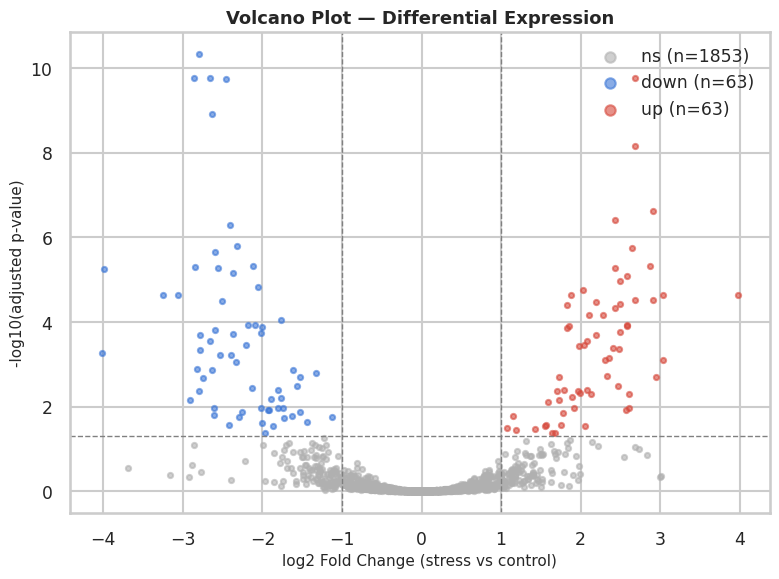

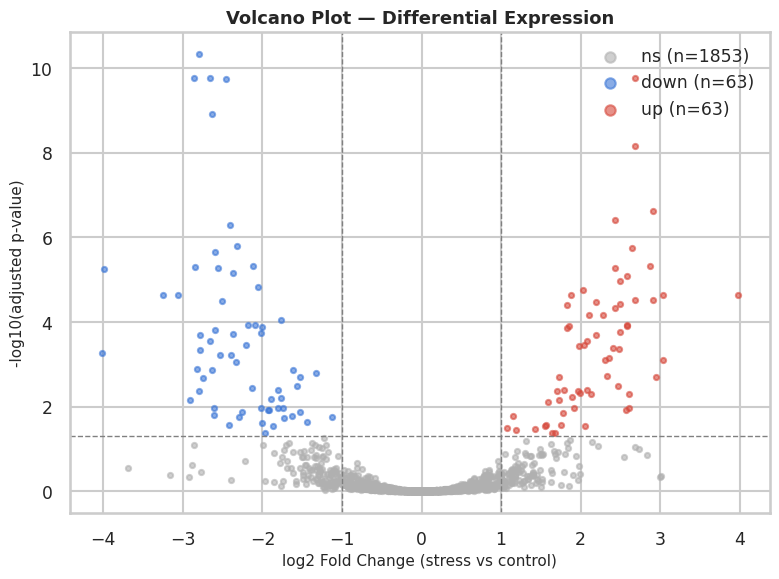

In [2]:
plot_volcano(deg_summary.full_table, config.alpha, config.lfc_threshold, config.figures_dir)

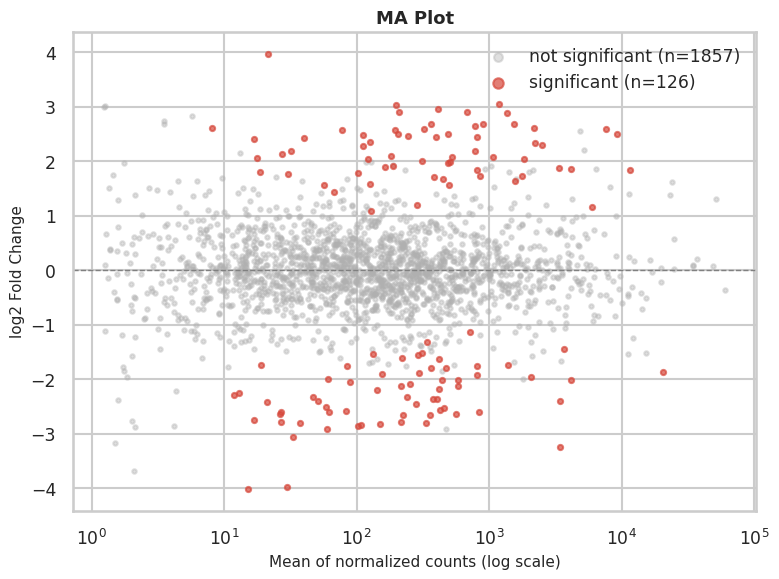

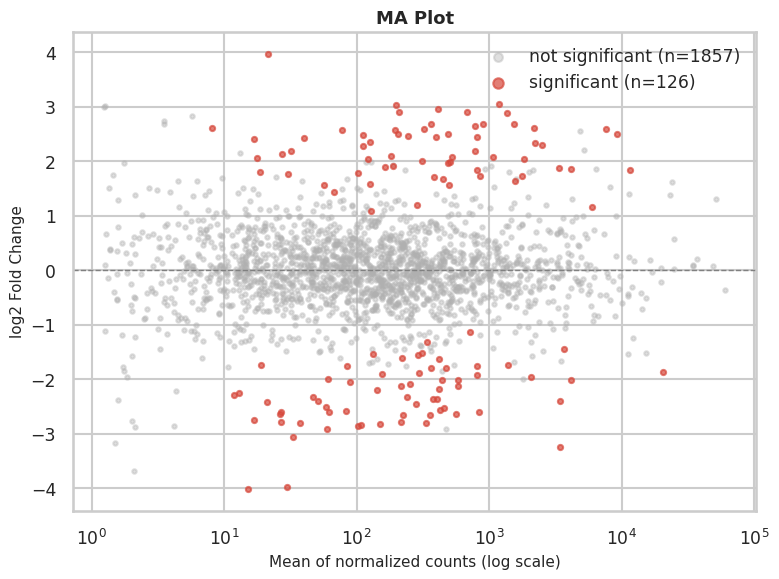

In [3]:
plot_ma(deg_summary.full_table, config.alpha, config.figures_dir)

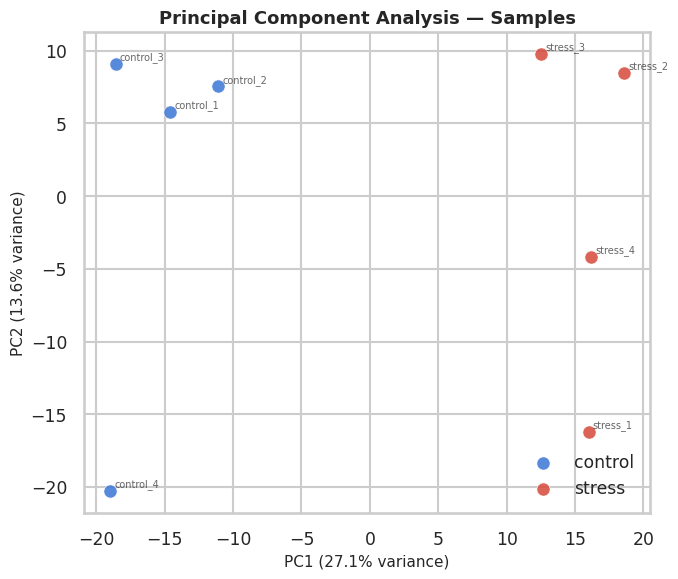

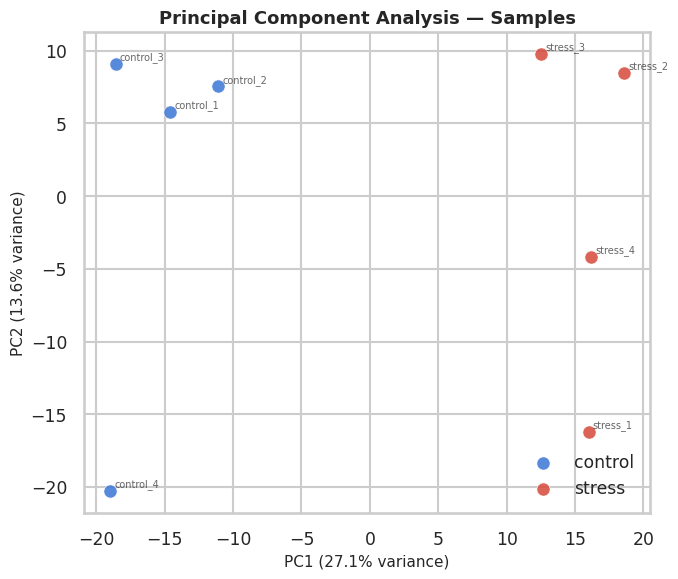

In [4]:
pca_result = run_pca(preprocessing.normalized_counts, n_components=2)
plot_pca(pca_result.coords, pca_result.explained_variance_ratio, dataset.metadata, 'condition', config.figures_dir)